In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set environment variables
import os

os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "single"
os.environ["MY_NUMBA_TARGET"] = "numba"

# Add cle_fun to PYTHON_PATH
import sys
sys.path.append("../../clonscal")

# unmodified theory


In [2]:
import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda
import src.scal as scal
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    calculate_stats_complex,
    gaussian_modified_density_drift_kernel
)

from src.numba_target import my_act_parallel_loop
from numba import cuda



Using single precision
Using C^1
Using Numba


In [3]:
import numpy as np
from scipy.integrate import quad
from numba import jit

# define obs that vanishes wrt rho
def n_moment_dse(x, order, sigma, lamb):
    return order*x**(order-1)-x**order * (sigma * x + lamb * x*x*x)

def n_moment(x, order):
    return x**order


# define rho and R
@jit
def action(x, sigma, lamb): return sigma/2*x**2+lamb/4*x**4

@jit
def rho(x, sigma, lamb): return np.exp(-action(x, sigma, lamb))

@jit
def R(x, r, a): return r*np.exp(-a*x**2/2)

@jit
def rho_tilde(x, r, a, sigma, lamb): return rho(x, sigma, lamb)+R(x, r, a)

# define partition sums
def z_rho(sigma, lamb): 
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

def z_rho_tilde(r, a, sigma, lamb): 
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

def z_R(r, a, sigma, lamb): 
    real_part = quad(lambda x: np.real(R(x, r, a)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)), -np.inf, np.inf)[0]
    return real_part+1j*imag_part

# define exp val of n_moment_dse wrt rho_tilde
@np.vectorize
def n_moment_dse_rho_tilde(order, r, a, sigma, lamb):
    real_part, _ = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)
    imag_part, _ = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)
    out = real_part + 1j*imag_part
    return out / z_rho_tilde(r, a, sigma, lamb)
    
# define exp val of n_moment_dse wrt rho
@np.vectorize
def n_moment_dse_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

# define exp val of n_moment_dse wrt R
@np.vectorize
def n_moment_dse_R(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)*n_moment_dse(x, order, sigma, lamb)), 
                     -np.inf, np.inf)[0]
    
    out = real_part + 1j*imag_part
    return out / z_R(r, a, sigma, lamb)

     
import scipy
# define analytic resul for n_moment_dse wrt R
@np.vectorize
def n_moment_dse_R_analytic(order, r, a, sigma, lamb):
    if order > 1:
        out = order*scipy.special.factorial2(order-2)/np.power(a, (order-1)//2)
    else: 
        out = 1
    out -= sigma*scipy.special.factorial2(order)/ np.power(a, (order+1)//2) 
    out -= lamb*scipy.special.factorial2(order+2)/np.power(a, (order+3)//2)
    return out

# define exp val of n_moment wrt rho
@np.vectorize
def n_moment_rho(order, sigma, lamb):
    real_part = quad(lambda x: np.real(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho(x, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho(sigma, lamb)

@np.vectorize
def n_moment_rho_tilde(order, r, a, sigma, lamb):
    real_part = quad(lambda x: np.real(rho_tilde(x, r, a, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(rho_tilde(x, r, a, sigma, lamb)*n_moment(x, order)), 
                     -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_rho_tilde(r, a, sigma, lamb)

@np.vectorize
def n_moment_R(order, r, a):
    real_part = quad(lambda x: np.real(R(x, r, a)*n_moment(x, order)), -np.inf, np.inf)[0]
    imag_part = quad(lambda x: np.imag(R(x, r, a)*n_moment(x, order)), -np.inf, np.inf)[0]
    out = real_part + 1j*imag_part
    return out / z_R(r, a, 0, 0)

In [4]:
def run_sim(params):
    param_key = "_".join(map(str, params.values()))
    sigma = params["sigma_abs"] * np.exp(1j*params["sigma_phase"])
    interaction = params["lambda_abs"]

    config = Config(
                    steps = params["steps"],
                    dt = params["dt"], 
                    trajs = params["trajs"], 
                    dims = [1], 
                    sigma = sigma, 
                    interaction = interaction, 
                    ada_step = True,
                    mean_dS_max = params["mean_dS_max"],
                    )
    
    sim_dse = ComplexLangevinSimulation(config)

    bins_p = params["bins_p"]  # Number of p bins
    bins_u = params["bins_u"]  # Number of u bins
    hist_p = np.zeros((bins_p, bins_p), dtype=scal.SCAL_TYPE_REAL)
    hist_u = np.zeros(bins_u, dtype=scal.SCAL_TYPE_REAL)
    
    if use_cuda:
        hist_u = cuda.to_device(hist_u)
        hist_p = cuda.to_device(hist_p)
        gpu_handler = GPU_handler(sim_dse)
        gpu_handler.to_device()

    # reigster observables
    sim_dse.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=True, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('3_moment', obs_kernel=n_moment_kernel, const_param={"order" : 3},  langevin_history=False, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('4_moment', obs_kernel=n_moment_kernel, const_param={"order" : 4},  langevin_history=False, thermal_time=0, auto_corr=0)
    
    sim_dse.register_observable('dse_1_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 1}, langevin_history=True, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('dse_2_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 2}, langevin_history=True, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('dse_3_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 3}, langevin_history=False, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('dse_4_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 4}, langevin_history=False, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('abs_drift', obs_kernel=abs_drift, langevin_history=False, thermal_time=0, auto_corr=0)
    

    # run the sim
    for idx in tqdm(range(params["steps"])):
        sim_dse.step()
        for name, tr in sim_dse.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()

        # update histograms
        p_tracker = sim_dse.trackers["1_moment"]
        u_tracker = sim_dse.trackers["abs_drift"]
        my_act_parallel_loop(update_histogram_complex, p_tracker.equilibrated_trajs, params["trajs"], p_tracker.result, hist_p, params["bins_p"], params["p_min_real"], params["p_max_real"], params["p_min_imag"], params["p_max_imag"])
        my_act_parallel_loop(update_histogram_real, u_tracker.equilibrated_trajs, params["trajs"], u_tracker.result, hist_u, params["bins_u"], params["u_min"], params["u_max"])
        if use_cuda: cuda.synchronize()
    
    sim_dse.finish()
    if use_cuda:
        hist_u = hist_u.copy_to_host()
        hist_p = hist_p.copy_to_host()

    results = {'params': params}

    for name, tr in sim_dse.trackers.items():
        mean, sem_real, sem_imag = calculate_stats_complex(tr.rolling_mean, tr.rolling_sqr_mean_real, tr.rolling_sqr_mean_imag, tr.counter)
        results[name] = {}
        results[name]["mean_real"] = mean.real
        results[name]["mean_imag"] = mean.imag
        results[name]["sem_real"] = sem_real
        results[name]["sem_imag"] = sem_imag
    
    return results, param_key, hist_p, hist_u, sim_dse

In [5]:
def plot_langdyn(parameters, sim):
    for key, value in parameters.items():
        print(key, "->", value)

    sigma = parameters["sigma_abs"]*np.exp(1j*parameters["sigma_phase"])
    lamb = parameters["lambda_abs"]
    mean_dS_max = parameters["mean_dS_max"]

    fig, ax = plt.subplots(2,2, figsize=(15, 5), sharex="col")
    ax = ax.flatten()

    fig.suptitle(f"Langevin dynamics avergaed over {parameters['trajs']} trajectories \n $\sigma = {{{np.round(np.real(sigma), 5)+1j*np.round(np.imag(sigma), 5)}}}$;   $\lambda = {{{np.round(lamb, 5)}}}$;  mean ds max = {mean_dS_max}")

    res_dse1_mom = sim.trackers["dse_1_moment"].history_result
    lt = sim.trackers["dse_1_moment"].history_meas_times
    ana = n_moment_dse_rho(1, sigma, lamb)

    ax[0].scatter(lt, res_dse1_mom.real, s = 1)
    ax[2].scatter(lt, res_dse1_mom.imag, s = 1)
    ax[0].hlines(ana.real, 0, parameters["steps"]*parameters["dt"], color = "black", label = "scipy")
    ax[2].hlines(ana.imag, 0, parameters["steps"]*parameters["dt"], color = "black", label = "scipy")
    ax[0].set_title(rf"$\mathcal{{O}} = 1-z(\sigma z+\lambda z^2)$")
    ax[0].set_ylabel(rf"real $\langle \mathcal{{O}} \rangle$")
    ax[2].set_ylabel(rf"imag $\langle \mathcal{{O}} \rangle$")


    res_2_mom = sim.trackers["2_moment"].history_result
    lt = sim.trackers["2_moment"].history_meas_times
    ana = n_moment_rho(2, parameters["sigma_abs"]*np.exp(1j*parameters["sigma_phase"]), parameters["lambda_abs"])

    ax[1].scatter(lt, res_2_mom.real, s = 1)
    ax[3].scatter(lt, res_2_mom.imag, s = 1)
    ax[1].hlines(ana.real, 0, parameters["steps"]*parameters["dt"], color = "black", label = "scipy")
    ax[3].hlines(ana.imag, 0, parameters["steps"]*parameters["dt"], color = "black", label = "scipy")
    ax[1].set_title(rf"$\mathcal{{O}} = z^2$")

#### Measure the thermalization time for the unmodified theory 

In [37]:
steps = int(1e5)
trajs = int(1e3)
dt = 1e-3

sigma = 1+1j
parameters0 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 50
    }

results0, param_key0, hist_p0, hist_u0, sim0 = run_sim(parameters0)

100%|██████████| 100000/100000 [00:55<00:00, 1812.98it/s]


steps -> 100000
trajs -> 1000
dt -> 0.001
sigma_abs -> 1.4142135623730951
sigma_phase -> 0.7853981633974483
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 50


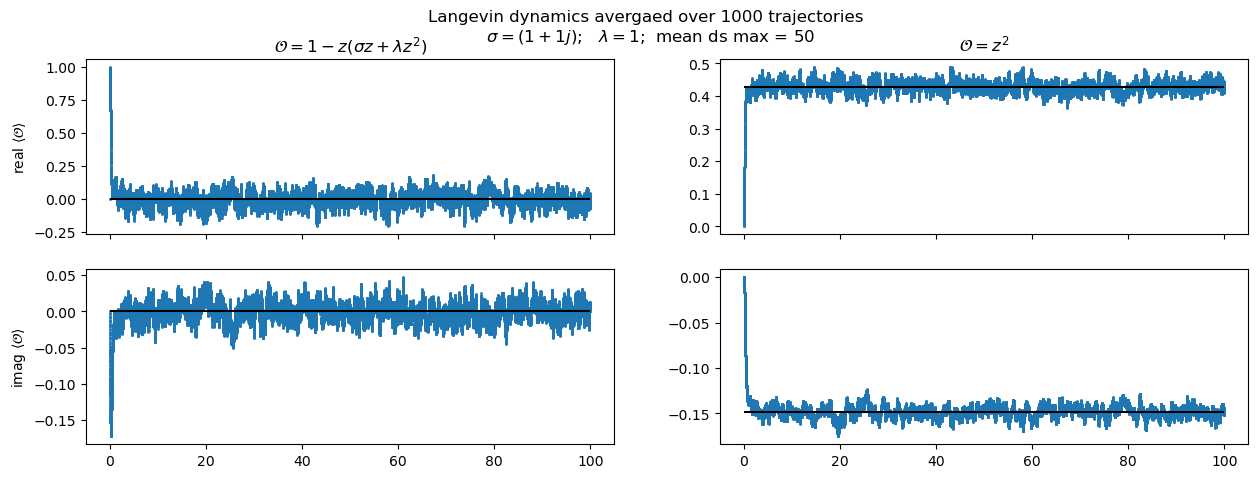

In [87]:
plot_langdyn(parameters0, sim0)

In [39]:
steps = int(1e5)
trajs = int(1e3)
dt = 1e-3

sigma = 1+1j
parameters1 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 10
    }

results1, param_key1, hist_p1, hist_u1, sim1 = run_sim(parameters1)

100%|██████████| 100000/100000 [00:55<00:00, 1804.24it/s]


steps -> 100000
trajs -> 1000
dt -> 0.001
sigma_abs -> 1.4142135623730951
sigma_phase -> 0.7853981633974483
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 10


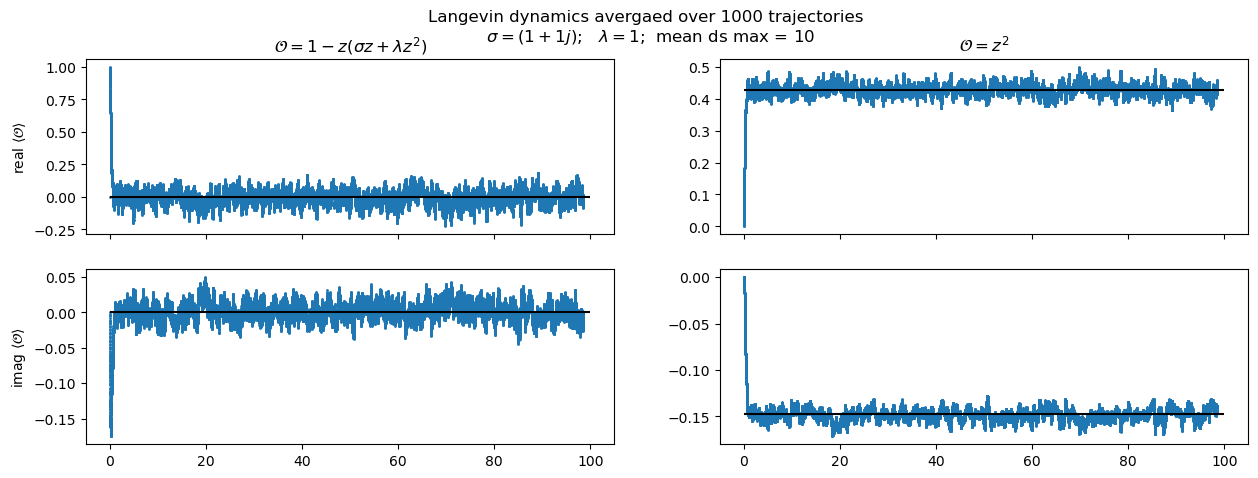

In [88]:
plot_langdyn(parameters1, sim1)

Simulations of the unmodified theory for lambda = 1 in phases of broken and unbroken symmetry. Testing different parameters in ada step.

In [71]:
steps = int(2e5)
trajs = int(1e3)
dt = 1e-4

sigma = -1+1j
parameters3 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 100
    }

results3, param_key3, hist_p3, hist_u3, sim3 = run_sim(parameters3)

100%|██████████| 200000/200000 [01:51<00:00, 1788.70it/s]


steps -> 200000
trajs -> 1000
dt -> 0.0001
sigma_abs -> 1.4142135623730951
sigma_phase -> 2.356194490192345
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 100


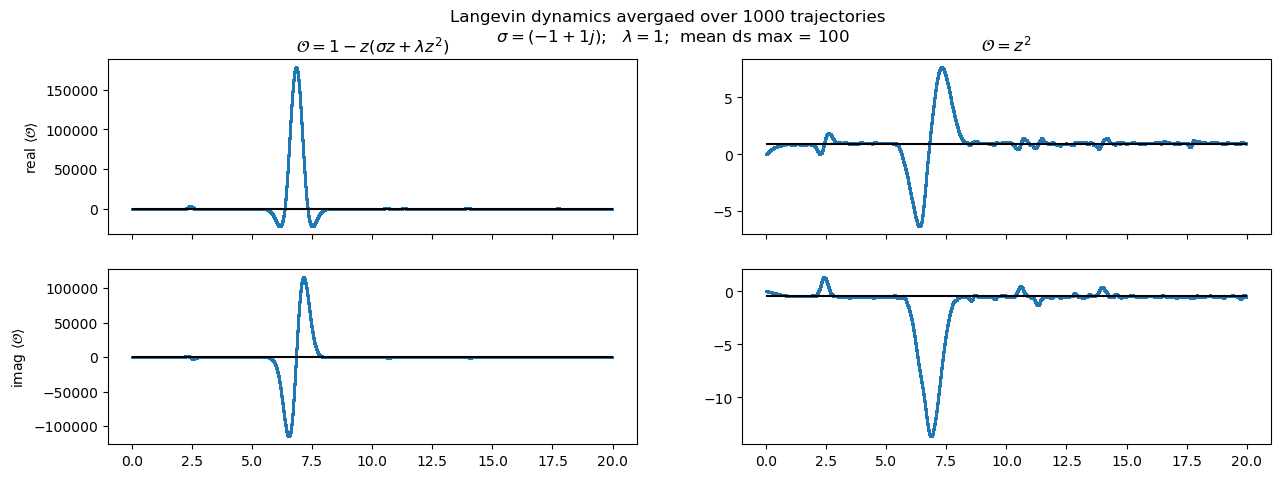

In [89]:
plot_langdyn(parameters3, sim3)

In [73]:
steps = int(2e5)
trajs = int(1e3)
dt = 1e-4

sigma = -1+1j
parameters4 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 50
    }

results4, param_key4, hist_p4, hist_u4, sim4 = run_sim(parameters4)

100%|██████████| 200000/200000 [01:52<00:00, 1776.41it/s]


steps -> 200000
trajs -> 1000
dt -> 0.0001
sigma_abs -> 1.4142135623730951
sigma_phase -> 2.356194490192345
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 50


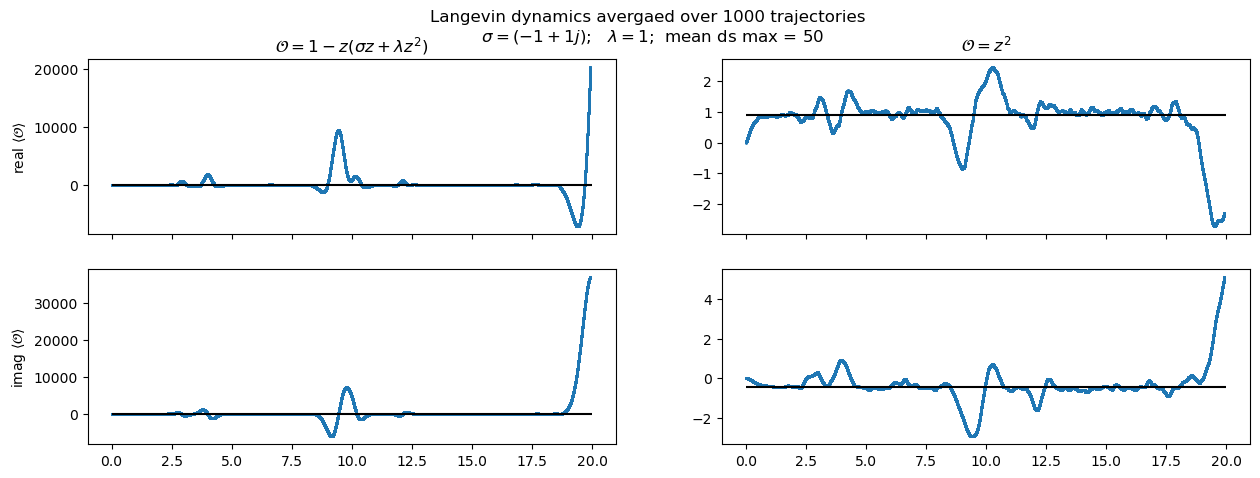

In [90]:
plot_langdyn(parameters4, sim4)

In [75]:
steps = int(2e5)
trajs = int(1e3)
dt = 1e-4

sigma = -1+1j
parameters5 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 20
    }

results5, param_key5, hist_p5, hist_u5, sim5 = run_sim(parameters5)

100%|██████████| 200000/200000 [01:51<00:00, 1795.38it/s]


steps -> 200000
trajs -> 1000
dt -> 0.0001
sigma_abs -> 1.4142135623730951
sigma_phase -> 2.356194490192345
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 20


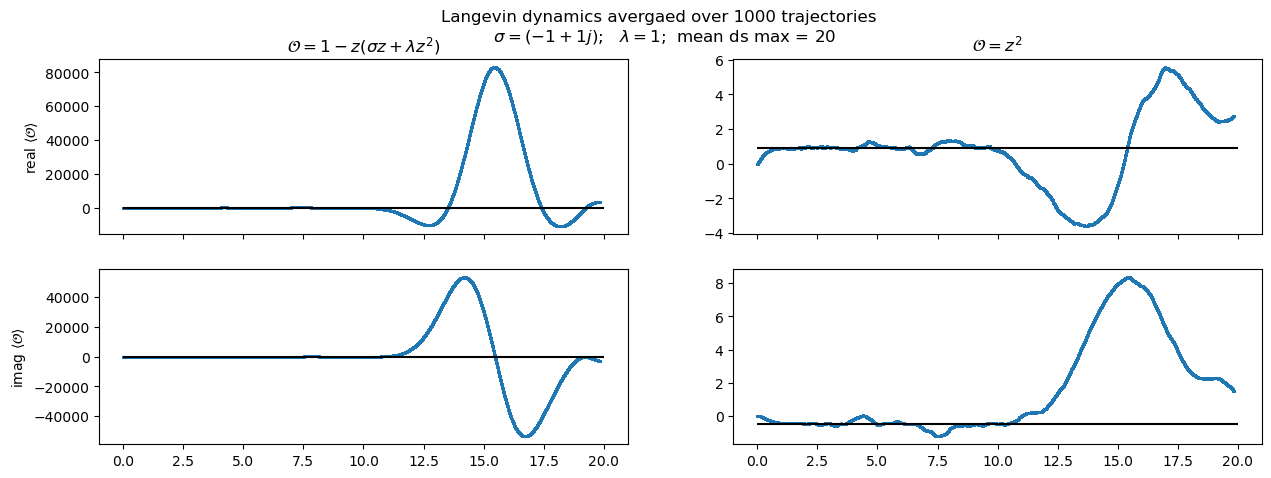

In [91]:
plot_langdyn(parameters5, sim5)

In [77]:
steps = int(2e5)
trajs = int(1e3)
dt = 1e-4

sigma = -1+1j
parameters6 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 5
    }

results6, param_key6, hist_p6, hist_u6, sim6 = run_sim(parameters6)

100%|██████████| 200000/200000 [01:52<00:00, 1772.89it/s]


In [83]:
print(parameters6["dt"]*parameters6["steps"])

20.0


steps -> 200000
trajs -> 1000
dt -> 0.0001
sigma_abs -> 1.4142135623730951
sigma_phase -> 2.356194490192345
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 5


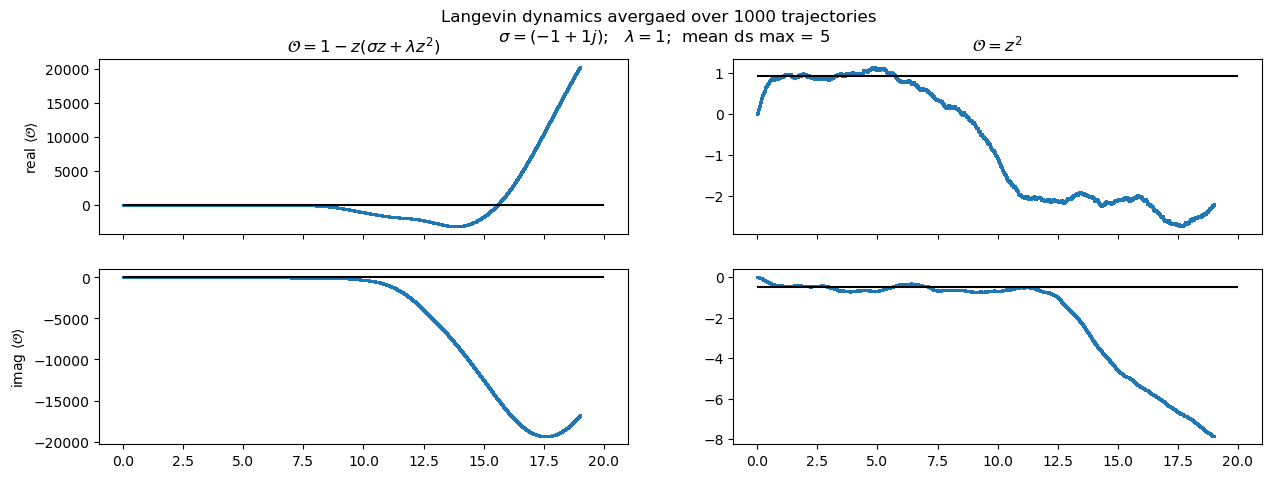

In [92]:
plot_langdyn(parameters6, sim6)

In [79]:
steps = int(2e5)
trajs = int(1e3)
dt = 1e-4

sigma = -1+1j
parameters7 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 1
    }

results7, param_key7, hist_p7, hist_u7, sim7 = run_sim(parameters7)

100%|██████████| 200000/200000 [01:51<00:00, 1786.60it/s]


steps -> 200000
trajs -> 1000
dt -> 0.0001
sigma_abs -> 1.4142135623730951
sigma_phase -> 2.356194490192345
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 1


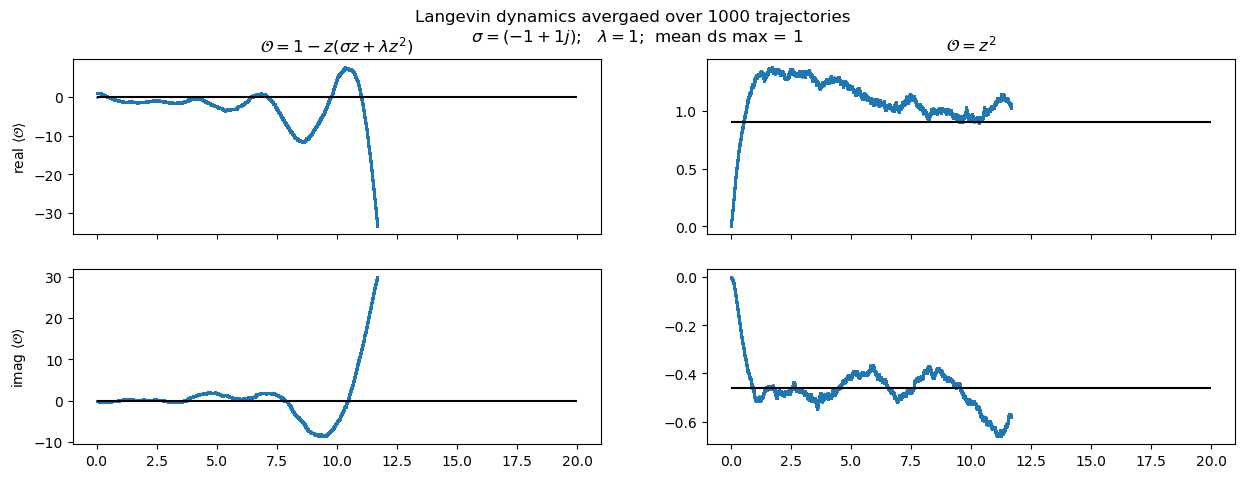

In [93]:
plot_langdyn(parameters7, sim7)

# Gaussian modified theory

In [150]:
import numpy as np
from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)
from tqdm import tqdm
from simulation.gpu_handler import GPU_handler
from src.numba_target import use_cuda
import src.scal as scal
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    calculate_stats_complex,
    gaussian_modified_density_drift_kernel
)

from src.numba_target import my_act_parallel_loop
from numba import cuda

In [359]:
def run_sim(params):
    param_key = "_".join(map(str, params.values()))
    sigma = params["sigma_abs"] * np.exp(1j*params["sigma_phase"])
    interaction = params["lambda_abs"]

    config = Config(
                    steps = params["steps"],
                    dt = params["dt"], 
                    trajs = params["trajs"], 
                    dims = [1], 
                    sigma = sigma, 
                    interaction = interaction, 
                    ada_step = True,
                    mean_dS_max = params["mean_dS_max"],
                    drift_kernel=gaussian_modified_density_drift_kernel,
                    mass_modification=params["mass_modification"], 
                    pullback=params["pullback"]
                    )
    
    sim_dse = ComplexLangevinSimulation(config)

    bins_p = params["bins_p"]  # Number of p bins
    bins_u = params["bins_u"]  # Number of u bins
    hist_p = np.zeros((bins_p, bins_p), dtype=scal.SCAL_TYPE_REAL)
    hist_u = np.zeros(bins_u, dtype=scal.SCAL_TYPE_REAL)
    
    if use_cuda:
        hist_u = cuda.to_device(hist_u)
        hist_p = cuda.to_device(hist_p)
        gpu_handler = GPU_handler(sim_dse)
        gpu_handler.to_device()

    # reigster observables
    sim_dse.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=True, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('3_moment', obs_kernel=n_moment_kernel, const_param={"order" : 3},  langevin_history=False, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('4_moment', obs_kernel=n_moment_kernel, const_param={"order" : 4},  langevin_history=False, thermal_time=0, auto_corr=0)
    
    sim_dse.register_observable('dse_1_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 1}, langevin_history=True, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('dse_2_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 2}, langevin_history=True, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('dse_3_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 3}, langevin_history=True, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('dse_4_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 4}, langevin_history=False, thermal_time=0, auto_corr=0)
    sim_dse.register_observable('abs_drift', obs_kernel=abs_drift, langevin_history=False, thermal_time=0, auto_corr=0)
    
    # run the sim
    for idx in tqdm(range(params["steps"])):
        sim_dse.step()
        for name, tr in sim_dse.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()

        # update histograms
        # p_tracker = sim_dse.trackers["1_moment"]
        # u_tracker = sim_dse.trackers["abs_drift"]
        # my_act_parallel_loop(update_histogram_complex, p_tracker.equilibrated_trajs, params["trajs"], p_tracker.result, hist_p, params["bins_p"], params["p_min_real"], params["p_max_real"], params["p_min_imag"], params["p_max_imag"])
        # my_act_parallel_loop(update_histogram_real, u_tracker.equilibrated_trajs, params["trajs"], u_tracker.result, hist_u, params["bins_u"], params["u_min"], params["u_max"])
        if use_cuda: cuda.synchronize()
    
    sim_dse.finish()
    if use_cuda:
        hist_u = hist_u.copy_to_host()
        hist_p = hist_p.copy_to_host()

    results = {'params': params}

    for name, tr in sim_dse.trackers.items():
        mean, sem_real, sem_imag = calculate_stats_complex(tr.rolling_mean, tr.rolling_sqr_mean_real, tr.rolling_sqr_mean_imag, tr.counter)
        results[name] = {}
        results[name]["mean_real"] = mean.real
        results[name]["mean_imag"] = mean.imag
        results[name]["sem_real"] = sem_real
        results[name]["sem_imag"] = sem_imag
    
    return results, param_key, hist_p, hist_u, sim_dse

In [360]:
def plot_langdyn(parameters, sim):
    for key, value in parameters.items():
        print(key, "->", value)

    sigma = parameters["sigma_abs"]*np.exp(1j*parameters["sigma_phase"])
    lamb = parameters["lambda_abs"]
    mean_dS_max = parameters["mean_dS_max"]
    pullback = parameters["pullback"]
    mass_modification = parameters["mass_modification"]

    fig, ax = plt.subplots(3,2, figsize=(15, 7), sharex = "col")
    ax = ax.flatten()



    fig.suptitle(f"Langevin dynamics avergaed over {parameters['trajs']} trajectories \n $\sigma = {{{np.round(np.real(sigma), 5)+1j*np.round(np.imag(sigma), 5)}}}$;   $\lambda = {{{np.round(lamb, 5)}}}$;  mean ds max = {mean_dS_max};  r = {pullback}; a = {mass_modification} ")
    ax[0].set_title("real")
    ax[1].set_title("imag")

    ax[0].set_ylabel(rf"$\langle z^2 \rangle$")
    ax[2].set_ylabel(rf"$\langle 1-z(\sigma z+\lambda z^3) \rangle$")

    res_2_mom = sim.trackers["2_moment"].history_result
    lt = sim.trackers["2_moment"].history_meas_times
    ana = n_moment_rho_tilde(2, pullback, mass_modification, parameters["sigma_abs"]*np.exp(1j*parameters["sigma_phase"]), parameters["lambda_abs"])
    ax[0].scatter(lt, res_2_mom.real, s = 1)
    ax[1].scatter(lt, res_2_mom.imag, s = 1)
    ax[0].hlines(ana.real, 0, parameters["steps"]*parameters["dt"], color = "black", label = "scipy")
    ax[1].hlines(ana.imag, 0, parameters["steps"]*parameters["dt"], color = "black", label = "scipy")

    res_dse1_mom = sim.trackers["dse_1_moment"].history_result
    lt = sim.trackers["dse_1_moment"].history_meas_times
    ana = n_moment_dse_rho_tilde(1, pullback, mass_modification, sigma, lamb)
    ax[2].scatter(lt, res_dse1_mom.real, s = 1)
    ax[3].scatter(lt, res_dse1_mom.imag, s = 1)
    ax[2].hlines(ana.real, 0, parameters["steps"]*parameters["dt"], color = "black", label = "scipy")
    ax[3].hlines(ana.imag, 0, parameters["steps"]*parameters["dt"], color = "black", label = "scipy")

    res_dse1_mom = sim.trackers["dse_3_moment"].history_result
    lt = sim.trackers["dse_3_moment"].history_meas_times
    ana = n_moment_dse_rho_tilde(3, pullback, mass_modification, sigma, lamb)
    ax[4].scatter(lt, res_dse1_mom.real, s = 1)
    ax[5].scatter(lt, res_dse1_mom.imag, s = 1)
    ax[4].hlines(ana.real, 0, parameters["steps"]*parameters["dt"], color = "black", label = "scipy")
    ax[5].hlines(ana.imag, 0, parameters["steps"]*parameters["dt"], color = "black", label = "scipy")

In [296]:
steps = int(1e5)
trajs = int(1e3)
dt = 1e-3

sigma = -1+1j
parameters8 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 10,
        "mass_modification": 2.5,
        "pullback": 100,
    }

results8, param_key8, hist_p8, hist_u8, sim8 = run_sim(parameters8)

100%|██████████| 100000/100000 [00:58<00:00, 1722.01it/s]


steps -> 100000
trajs -> 1000
dt -> 0.001
sigma_abs -> 1.4142135623730951
sigma_phase -> 2.356194490192345
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 10
mass_modification -> 2.5
pullback -> 100


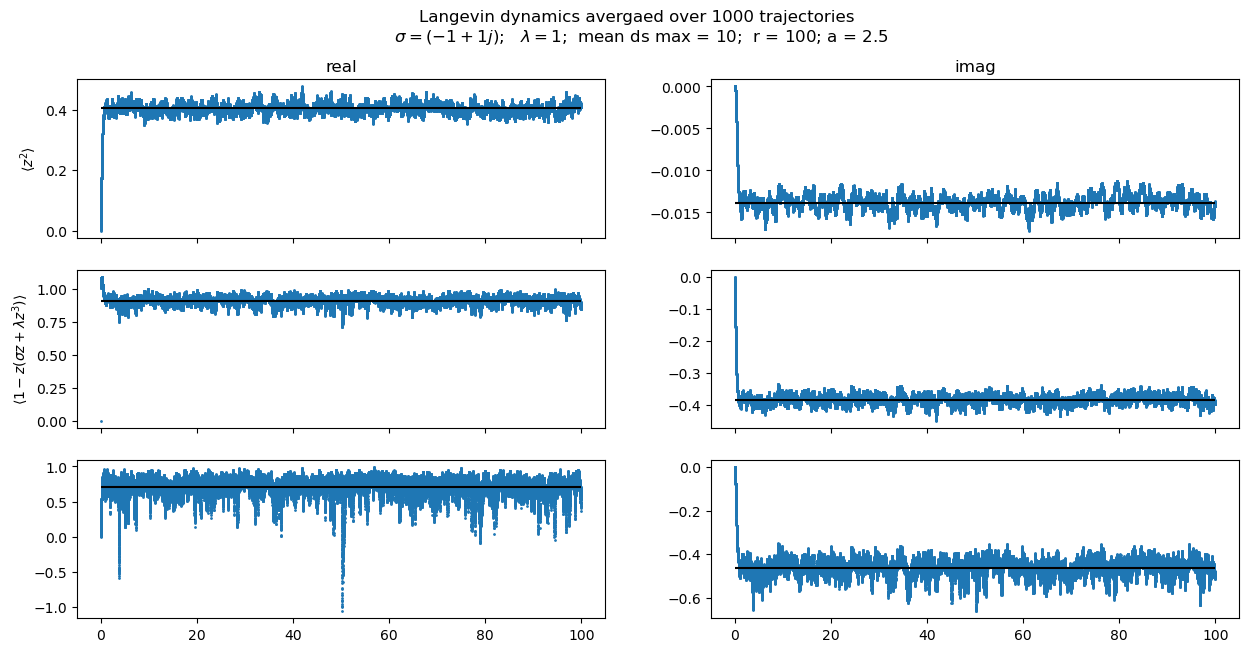

In [298]:
plot_langdyn(parameters8, sim8)

In [361]:
steps = int(1e5)
trajs = int(1e3)
dt = 1e-3

sigma = -1+1j
parameters9 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 2,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 10,
        "mass_modification": 2.5,
        "pullback": 100,
    }

results9, param_key9, hist_p9, hist_u9, sim9 = run_sim(parameters9)

100%|██████████| 100000/100000 [00:57<00:00, 1731.16it/s]


steps -> 100000
trajs -> 1000
dt -> 0.001
sigma_abs -> 1.4142135623730951
sigma_phase -> 2.356194490192345
lambda_abs -> 2
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 10
mass_modification -> 2.5
pullback -> 100


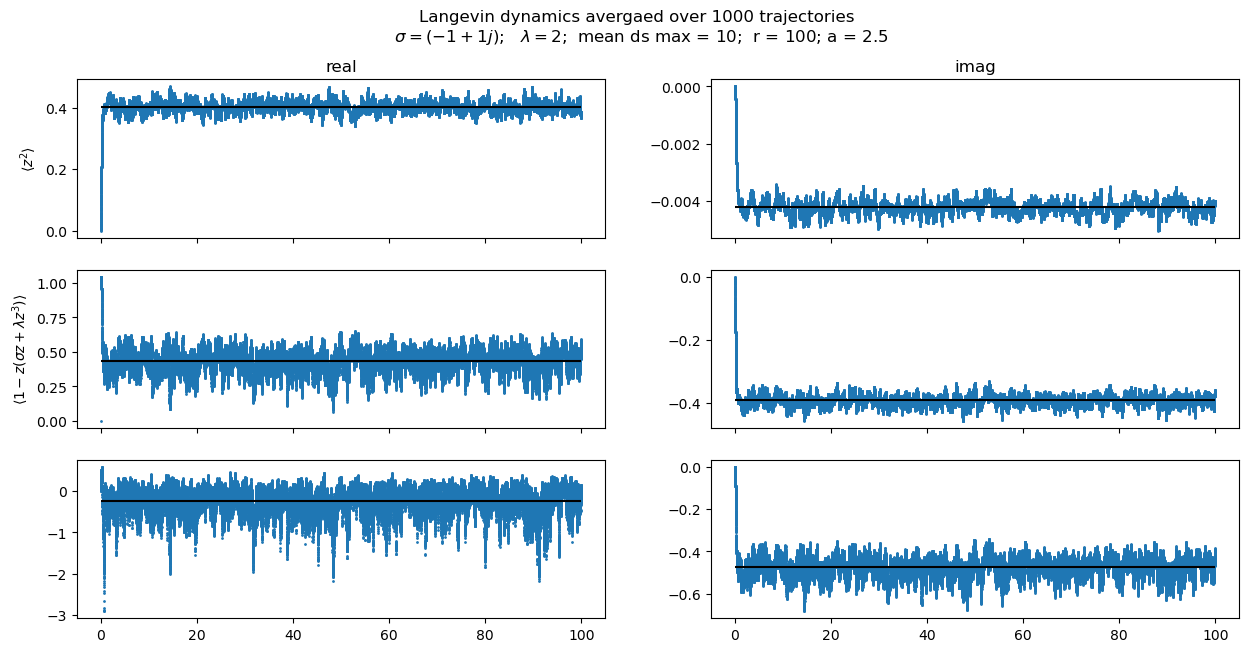

In [362]:
plot_langdyn(parameters9, sim9)

In [262]:
steps = int(1e5)
trajs = int(1e3)
dt = 1e-3

sigma = -1+1j
parameters9 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 100,
        "mass_modification": 0.5,
        "pullback": 100,
    }

results9, param_key9, hist_p9, hist_u9, sim9 = run_sim(parameters9)

100%|██████████| 100000/100000 [00:57<00:00, 1746.67it/s]


steps -> 100000
trajs -> 1000
dt -> 0.001
sigma_abs -> 1.4142135623730951
sigma_phase -> 2.356194490192345
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 100
mass_modification -> 0.5
pullback -> 100


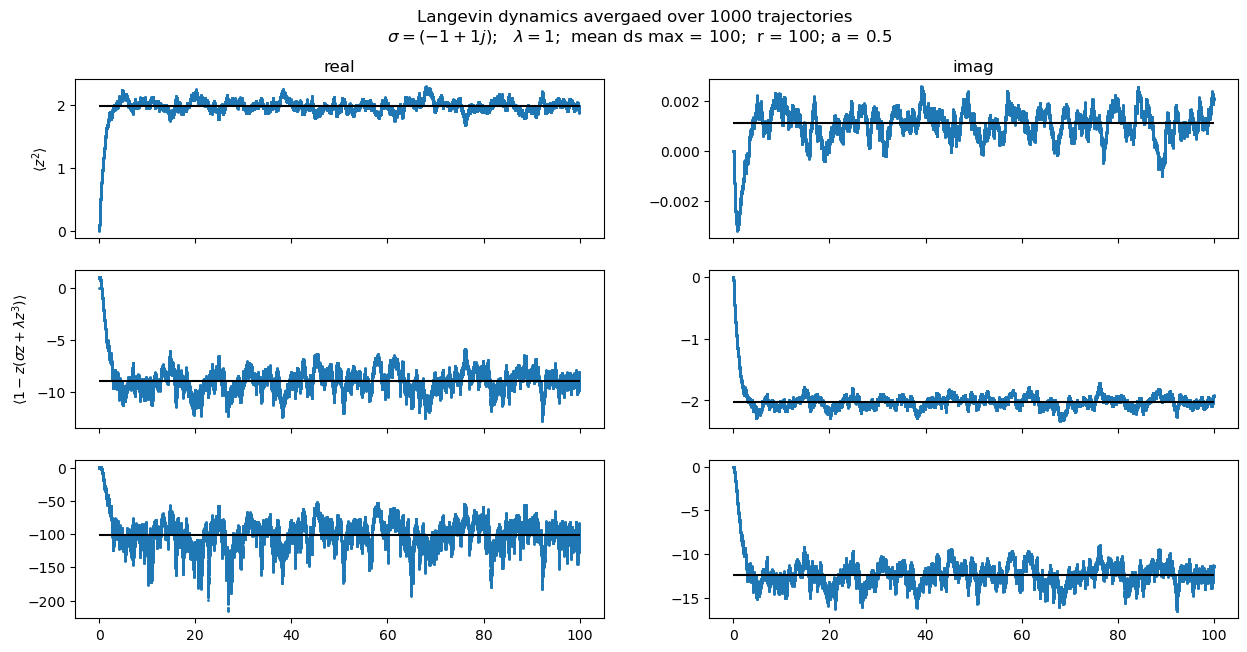

In [263]:
plot_langdyn(parameters9, sim9)

In [286]:
steps = int(1e5)
trajs = int(1e3)
dt = 1e-3

sigma = -1+1j
parameters10 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 10,
        "mass_modification": 2.5,
        "pullback": 100,
    }

results10, param_key10, hist_p10, hist_u10, sim10 = run_sim(parameters10)

100%|██████████| 100000/100000 [00:57<00:00, 1751.26it/s]


steps -> 100000
trajs -> 1000
dt -> 0.001
sigma_abs -> 1.4142135623730951
sigma_phase -> 2.356194490192345
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 10
mass_modification -> 2.5
pullback -> 100


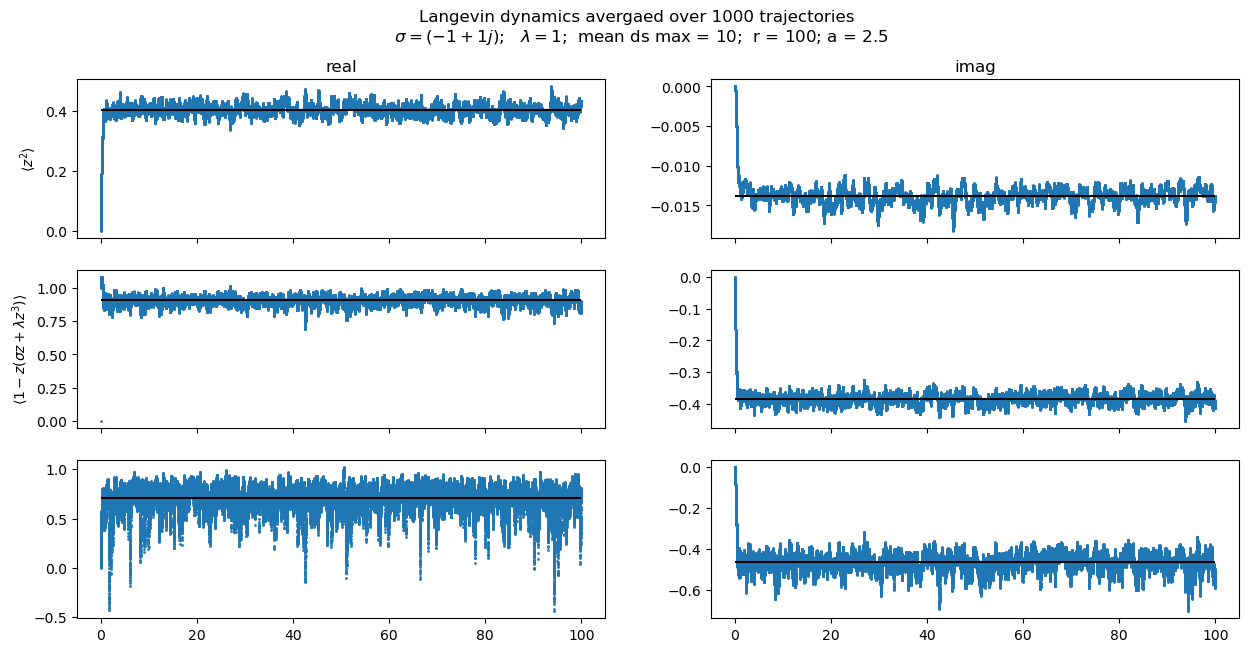

In [287]:
plot_langdyn(parameters10, sim10)

In [294]:
lt = sim10.trackers["dse_1_moment"].history_meas_times
sim10.trackers["dse_1_moment"].history_result[lt>5].mean()

(0.9056473-0.3832515j)

In [295]:
n_moment_dse_rho_tilde(1, 100, 2.5, -1+1j, 1)

array(0.90657557-0.38312564j)

In [292]:
lt = sim10.trackers["dse_3_moment"].history_meas_times
sim10.trackers["dse_3_moment"].history_result[lt>10].mean()

(0.7100551-0.46432883j)

In [293]:
n_moment_dse_rho_tilde(3, 100, 2.5, -1+1j, 1)

array(0.71117852-0.46362535j)

In [166]:
steps = int(1e5)
trajs = int(1e3)
dt = 1e-3

sigma = -1+1j
parameters9 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 50,
        "mass_modification": 0.5,
        "pullback": 50,
    }

results9, param_key9, hist_p9, hist_u9, sim9 = run_sim(parameters9)

100%|██████████| 100000/100000 [00:57<00:00, 1736.38it/s]


steps -> 100000
trajs -> 1000
dt -> 0.001
sigma_abs -> 1.4142135623730951
sigma_phase -> 2.356194490192345
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 50
mass_modification -> 0.5
pullback -> 50


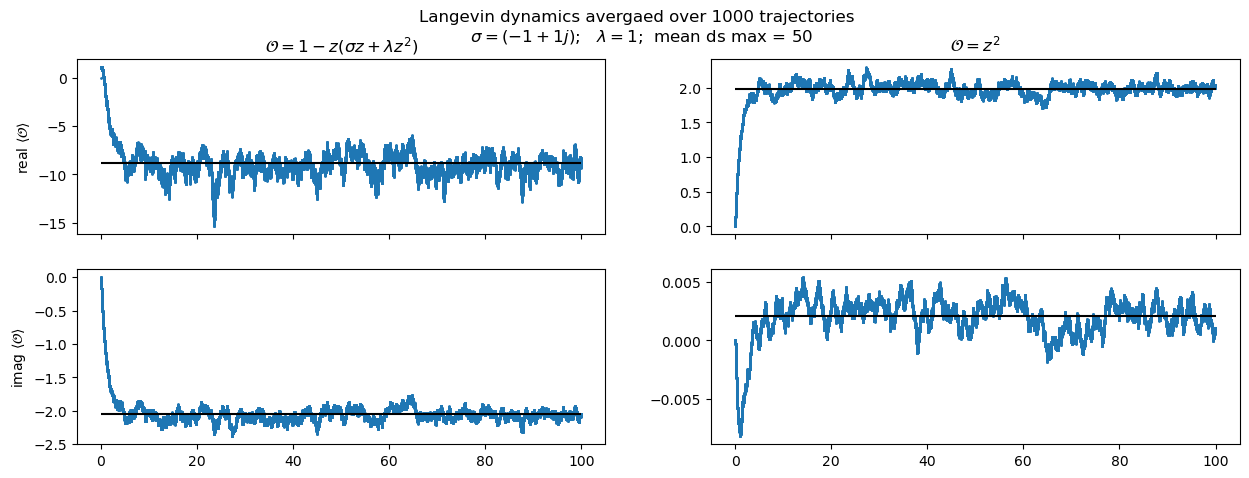

In [167]:
plot_langdyn(parameters9, sim9)

In [185]:
steps = int(1e5)
trajs = int(1e4)
dt = 1e-3

sigma = -1+1j
parameters10 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 100,
        "mass_modification": 0.5,
        "pullback": 50,
    }

results10, param_key10, hist_p10, hist_u10, sim10 = run_sim(parameters10)

100%|██████████| 100000/100000 [02:19<00:00, 719.28it/s]


steps -> 100000
trajs -> 10000
dt -> 0.001
sigma_abs -> 1.4142135623730951
sigma_phase -> 2.356194490192345
lambda_abs -> 1
bins_u -> 1000000
bins_p -> 1000
p_min_real -> -5
p_max_real -> 5
p_min_imag -> -5
p_max_imag -> 5
u_min -> 0.001
u_max -> 1000
mean_dS_max -> 100
mass_modification -> 0.5
pullback -> 50


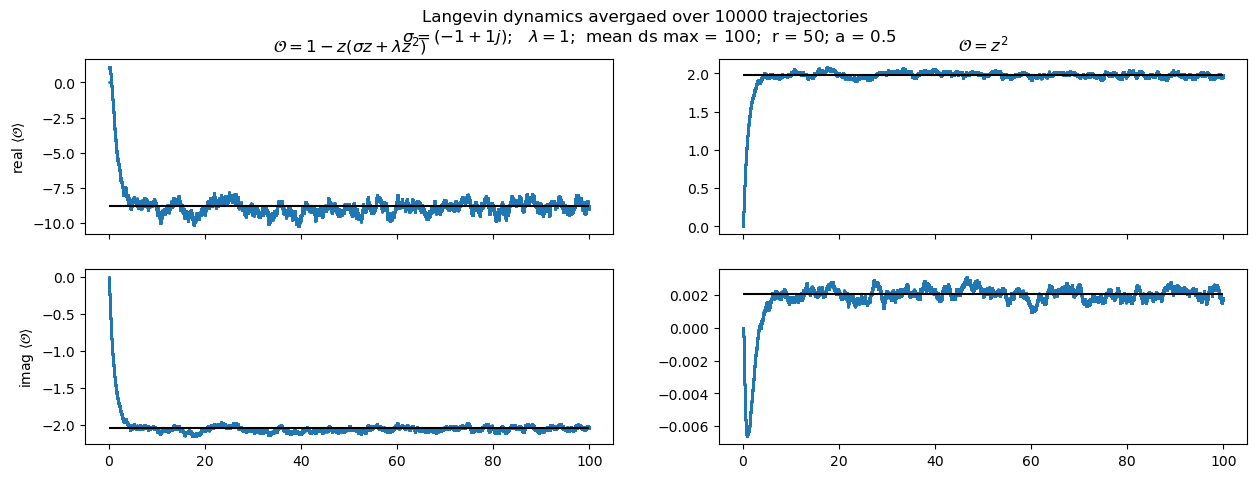

In [187]:
plot_langdyn(parameters10, sim10)

In [192]:
sim10.trackers["dse_1_moment"].history_result[sim10.trackers["dse_1_moment"].history_meas_times>10].mean()

(-8.925464-2.0552866j)

In [182]:
sim10.trackers["1_moment"].history_result[sim10.trackers["1_moment"].history_meas_times>40].mean()

(0.016190201-9.613235e-05j)

In [6]:
n_moment_dse_rho_tilde(1, 50, 0.5, -1+1j, 1)

array(-8.82888211-2.04755074j)

# Simulation

In [363]:
def run_sim(params):
    param_key = "_".join(map(str, params.values()))
    sigma = params["sigma_abs"] * np.exp(1j*params["sigma_phase"])
    interaction = params["lambda_abs"]

    config = Config(
                    steps = params["steps"],
                    dt = params["dt"], 
                    trajs = params["trajs"], 
                    dims = [1], 
                    sigma = sigma, 
                    interaction = interaction, 
                    ada_step = True,
                    mean_dS_max = params["mean_dS_max"],
                    drift_kernel=gaussian_modified_density_drift_kernel,
                    mass_modification=params["mass_modification"], 
                    pullback=params["pullback"]
                    )
    
    sim_dse = ComplexLangevinSimulation(config)

    bins_p = params["bins_p"]  # Number of p bins
    bins_u = params["bins_u"]  # Number of u bins
    hist_p = np.zeros((bins_p, bins_p), dtype=scal.SCAL_TYPE_REAL)
    hist_u = np.zeros(bins_u, dtype=scal.SCAL_TYPE_REAL)
    
    if use_cuda:
        hist_u = cuda.to_device(hist_u)
        hist_p = cuda.to_device(hist_p)
        gpu_handler = GPU_handler(sim_dse)
        gpu_handler.to_device()

    # reigster observables
    sim_dse.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=False, thermal_time=10, auto_corr=1)
    sim_dse.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=False, thermal_time=10, auto_corr=1)
    sim_dse.register_observable('3_moment', obs_kernel=n_moment_kernel, const_param={"order" : 3},  langevin_history=False, thermal_time=10, auto_corr=1)
    sim_dse.register_observable('4_moment', obs_kernel=n_moment_kernel, const_param={"order" : 4},  langevin_history=False, thermal_time=10, auto_corr=1)
    
    sim_dse.register_observable('dse_1_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 1}, langevin_history=False, thermal_time=10, auto_corr=1)
    sim_dse.register_observable('dse_2_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 2}, langevin_history=False, thermal_time=10, auto_corr=1)
    sim_dse.register_observable('dse_3_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 3}, langevin_history=False, thermal_time=10, auto_corr=1)
    sim_dse.register_observable('dse_4_moment', obs_kernel=dse_n_moment_kernel, const_param={'order': 4}, langevin_history=False, thermal_time=10, auto_corr=1)
    sim_dse.register_observable('abs_drift', obs_kernel=abs_drift, langevin_history=False, thermal_time=10, auto_corr=1)
    
    # run the sim
    for idx in tqdm(range(params["steps"])):
        sim_dse.step()
        for name, tr in sim_dse.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()

        # update histograms
        # p_tracker = sim_dse.trackers["1_moment"]
        # u_tracker = sim_dse.trackers["abs_drift"]
        # my_act_parallel_loop(update_histogram_complex, p_tracker.equilibrated_trajs, params["trajs"], p_tracker.result, hist_p, params["bins_p"], params["p_min_real"], params["p_max_real"], params["p_min_imag"], params["p_max_imag"])
        # my_act_parallel_loop(update_histogram_real, u_tracker.equilibrated_trajs, params["trajs"], u_tracker.result, hist_u, params["bins_u"], params["u_min"], params["u_max"])
        if use_cuda: cuda.synchronize()
    
    sim_dse.finish()
    if use_cuda:
        hist_u = hist_u.copy_to_host()
        hist_p = hist_p.copy_to_host()

    results = {'params': params}

    for name, tr in sim_dse.trackers.items():
        mean, sem_real, sem_imag = calculate_stats_complex(tr.rolling_mean, tr.rolling_sqr_mean_real, tr.rolling_sqr_mean_imag, tr.counter)
        results[name] = {}
        results[name]["mean_real"] = mean.real
        results[name]["mean_imag"] = mean.imag
        results[name]["sem_real"] = sem_real
        results[name]["sem_imag"] = sem_imag
    
    return results, param_key, hist_p, hist_u, sim_dse

In [385]:
steps = int(1e6)
trajs = int(1e4)
dt = 1e-4

sigma = -1+1j
parameters99 = {
        "steps": steps,
        "trajs": trajs,
        "dt": dt,
        "sigma_abs": np.abs(sigma),
        "sigma_phase": np.angle(sigma),
        "lambda_abs": 1,
        "bins_u": int(1e6),
        "bins_p": int(1e3),
        "p_min_real": -5,
        "p_max_real": 5,
        "p_min_imag": -5,
        "p_max_imag": 5,
        "u_min": 1e-3,
        "u_max": int(1e3),
        "mean_dS_max": 10,
        "mass_modification": 2.5,
        "pullback": 100,
    }

results99, param_key99, hist_p99, hist_u99, sim99 = run_sim(parameters99)


100%|██████████| 1000000/1000000 [12:02<00:00, 1384.94it/s]


In [386]:
results99["dse_1_moment"]

{'mean_real': 0.9049082638888889,
 'mean_imag': -0.38416555555555554,
 'sem_real': 0.0011645663266106206,
 'sem_imag': 0.000533310820800582}

In [381]:
0.7147151666666667-0.001989522581076445

0.7127256440855902

In [12]:
1.291674977277448+2*0.0005506392780206454

1.2927762558334894

In [15]:
n_moment_dse_rho_tilde(1, 100, 2.5, -2+1j, 1)

array(1.29472794-0.35359769j)

In [419]:
pullback = parameters99["pullback"]
mass_modification = parameters99["mass_modification"]
sigma = parameters99["sigma_abs"]*np.exp(1j*parameters99["sigma_phase"])
lamb = parameters99["lambda_abs"]

dse_R = n_moment_dse_R(1, pullback, mass_modification, sigma, lamb)
dse_rho_tilde = results99["dse_1_moment"]["mean_real"] + 1j*results99["dse_1_moment"]["mean_imag"]
dse_rho_tilde_sem = results99["dse_1_moment"]["sem_real"] + 1j*results99["dse_1_moment"]["sem_imag"]
Q_cl = 1/(dse_R/dse_rho_tilde-1)
Q_ana = 1/(dse_R/n_moment_dse_rho_tilde(1, pullback, mass_modification, sigma, lamb)-1)
Q_cl_error_prop = dse_R/(dse_R-dse_rho_tilde)**2*dse_rho_tilde_sem

print(Q_ana)
print(Q_cl)

(40.07933845070798+21.839839494899902j)
(41.254110888734395+17.82898729715766j)


In [420]:
Q_cl_error_prop

(-0.18069743736942107+2.67937160927796j)

In [423]:
biased_2_mom_mean = results99["2_moment"]["mean_real"]+1j*results99["2_moment"]["mean_imag"]
biased_2_mom_sem = results99["2_moment"]["sem_real"]+1j*results99["2_moment"]["sem_imag"]
biased_2_mom_sem

(0.0005995798706097042+3.221626875208574e-05j)

In [424]:
biased_2_mom_mean + Q_cl*(biased_2_mom_mean-n_moment_R(2, pullback, mass_modification))

(0.9110422949695196-0.4753083230346857j)

In [425]:
biased_2_mom_sem+Q_cl_error_prop*biased_2_mom_mean+Q_cl_error_prop*biased_2_mom_sem-Q_cl_error_prop*n_moment_R(2, pullback, mass_modification)

(0.03646943679985932+0.020853870823932752j)

In [428]:
(0.9110422949695196)+0.03646943679985932

0.947511731769379

In [426]:
n_moment_rho_tilde(2, pullback, mass_modification, sigma, lamb) - Q_ana*(n_moment_R(2, pullback, mass_modification)-n_moment_rho_tilde(2, pullback, mass_modification, sigma, lamb))

(0.9094730215165159-0.4588115175438045j)

In [418]:
n_moment_rho(2, sigma, lamb)

array(0.90947302-0.45881152j)

3rd dse mom

In [442]:
pullback = parameters99["pullback"]
mass_modification = parameters99["mass_modification"]
sigma = parameters99["sigma_abs"]*np.exp(1j*parameters99["sigma_phase"])
lamb = parameters99["lambda_abs"]

dse_R = n_moment_dse_R(3, pullback, mass_modification, sigma, lamb)
dse_rho_tilde = results99["dse_3_moment"]["mean_real"] + 1j*results99["dse_3_moment"]["mean_imag"]
dse_rho_tilde_sem = results99["dse_3_moment"]["sem_real"] + 1j*results99["dse_3_moment"]["sem_imag"]
Q_cl = 1/(dse_R/dse_rho_tilde-1)
Q_ana = 1/(dse_R/n_moment_dse_rho_tilde(3, pullback, mass_modification, sigma, lamb)-1)
Q_cl_error_prop = dse_R/(dse_R-dse_rho_tilde)**2*dse_rho_tilde_sem

print(Q_ana)
print(Q_cl)

(40.079338450709194+21.839839494884803j)
(46.24524553222549+19.945328495393603j)


In [443]:
biased_2_mom_mean = results99["2_moment"]["mean_real"]+1j*results99["2_moment"]["mean_imag"]
biased_2_mom_sem = results99["2_moment"]["sem_real"]+1j*results99["2_moment"]["sem_imag"]
biased_2_mom_mean + Q_cl*(biased_2_mom_mean-n_moment_R(2, pullback, mass_modification))

(0.9715512029118394-0.5313880860632177j)

In [ ]:
biased_2_mom_sem+Q_cl_error_prop*biased_2_mom_mean+Q_cl_error_prop*biased_2_mom_sem-Q_cl_error_prop*n_moment_R(2, pullback, mass_modification)

(0.1791599232192984+0.12203928345305481j)